In [1]:
import sys
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sys.path.append(os.path.abspath(os.path.join("..", "")))
from Data.clean_data import get_ai_developer_dataset
df = get_ai_developer_dataset()
df

/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/bibo/.cache/kagglehub/datasets/ayeshasiddiqa123/ai-development/versions/1


,Hours_Coding,Lines_of_Code,Bugs_Found,Bugs_Fixed,AI_Usage_Hours,Sleep_Hours,Cognitive_Load,Task_Success_Rate,Coffee_Intake,Stress_Level,Task_Duration_Hours,Commits,Errors
0,7,416,9,7,6,5.9,92,34,7,99,10.5,20,3
1,4,269,16,13,5,5.1,85,36,2,100,9.5,17,8
2,11,439,3,0,2,6.2,38,79,2,55,18.3,35,2
3,8,472,15,9,4,4.2,26,94,5,30,12.6,28,4
4,5,265,19,16,5,8.1,82,33,6,82,7.0,25,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,10,660,14,13,0,5.5,21,80,2,30,5.2,20,5
996,9,484,13,11,1,8.8,34,78,0,39,4.7,37,1
997,2,128,4,0,3,8.7,42,74,3,49,2.8,5,7
998,8,266,5,3,1,5.7,48,51,0,63,11.8,9,0


In [ ]:
y = df['Task_Duration_Hours']
feature_cols = [
    'Hours_Coding', 
    'Lines_of_Code', 
    'Bugs_Found', 
    'AI_Usage_Hours', 
    'Sleep_Hours', 
    'Cognitive_Load', 
    'Coffee_Intake', 
    'Stress_Level', 
    'Commits'
]
X = df[feature_cols]

,Hours_Coding,Lines_of_Code,Bugs_Found,AI_Usage_Hours,Sleep_Hours,Cognitive_Load,Coffee_Intake,Stress_Level,Commits
0,7,416,9,6,5.9,92,7,99,20
1,4,269,16,5,5.1,85,2,100,17
2,11,439,3,2,6.2,38,2,55,35
3,8,472,15,4,4.2,26,5,30,28
4,5,265,19,5,8.1,82,6,82,25
...,...,...,...,...,...,...,...,...,...
995,10,660,14,0,5.5,21,2,30,20
996,9,484,13,1,8.8,34,0,39,37
997,2,128,4,3,8.7,42,3,49,5
998,8,266,5,1,5.7,48,0,63,9


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Linear Regression

In [4]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

r2_score(y_test, y_pred_lr)

0.5677410031426162

In [5]:
print(f"Mean Absolute Error (MAE): {mae_lr:.2f} hours")
print(f"Root Mean Squared Error (RMSE): {rmse_lr:.2f} hours")
print(f"R-squared (R2) Score: {r2_lr:.4f}")

Mean Absolute Error (MAE): 3.00 hours
Root Mean Squared Error (RMSE): 3.93 hours
R-squared (R2) Score: 0.5677


## Random Forest Regressor

In [6]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train) 

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_score(y_test, y_pred_rf)


0.5337256546367217

In [7]:
r2_rf = r2_score(y_test, y_pred_rf)
print("--- Random Forest Results ---")
print(f"Mean Absolute Error (MAE): {mae_rf:.2f} hours")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.2f} hours")
print(f"R-squared (R2) Score: {r2_rf:.4f}")

--- Random Forest Results ---
Mean Absolute Error (MAE): 3.13 hours
Root Mean Squared Error (RMSE): 4.08 hours
R-squared (R2) Score: 0.5337


/var/folders/3b/rk4wlpz91b550937x0t31krc0000gn/T/ipykernel_1833/52161316.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=np.array(feature_cols)[indices], palette='viridis')


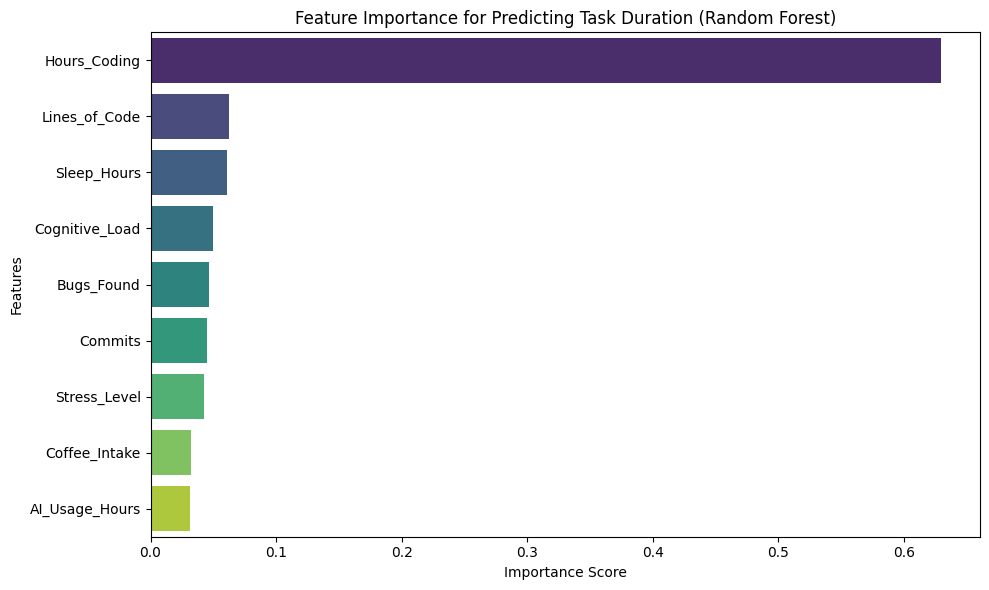

In [8]:
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=np.array(feature_cols)[indices], palette='viridis')
plt.title('Feature Importance for Predicting Task Duration (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()


In [9]:
coefficients = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr_model.coef_
}).sort_values(by='Coefficient', ascending=False)
print(coefficients.to_string(index=False))


       Feature  Coefficient
  Hours_Coding     4.640883
 Lines_of_Code     0.241190
  Stress_Level     0.224844
 Coffee_Intake     0.216396
    Bugs_Found    -0.130076
       Commits    -0.138762
AI_Usage_Hours    -0.139792
   Sleep_Hours    -0.177509
Cognitive_Load    -0.284615


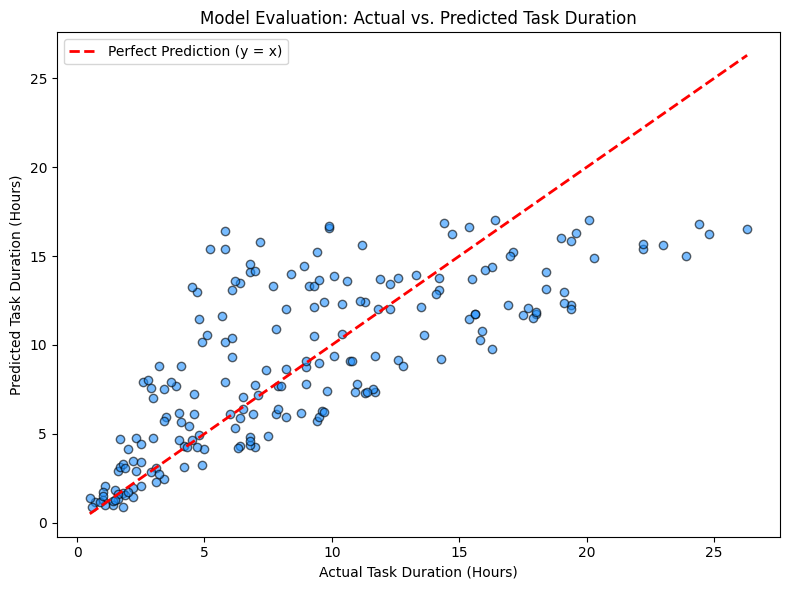

In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.6, color='dodgerblue', edgecolors='k')

min_val = min(y_test.min(), y_pred_lr.min())
max_val = max(y_test.max(), y_pred_lr.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction (y = x)')

plt.title('Model Evaluation: Actual vs. Predicted Task Duration')
plt.xlabel('Actual Task Duration (Hours)')
plt.ylabel('Predicted Task Duration (Hours)')
plt.legend()
plt.tight_layout()
plt.show()


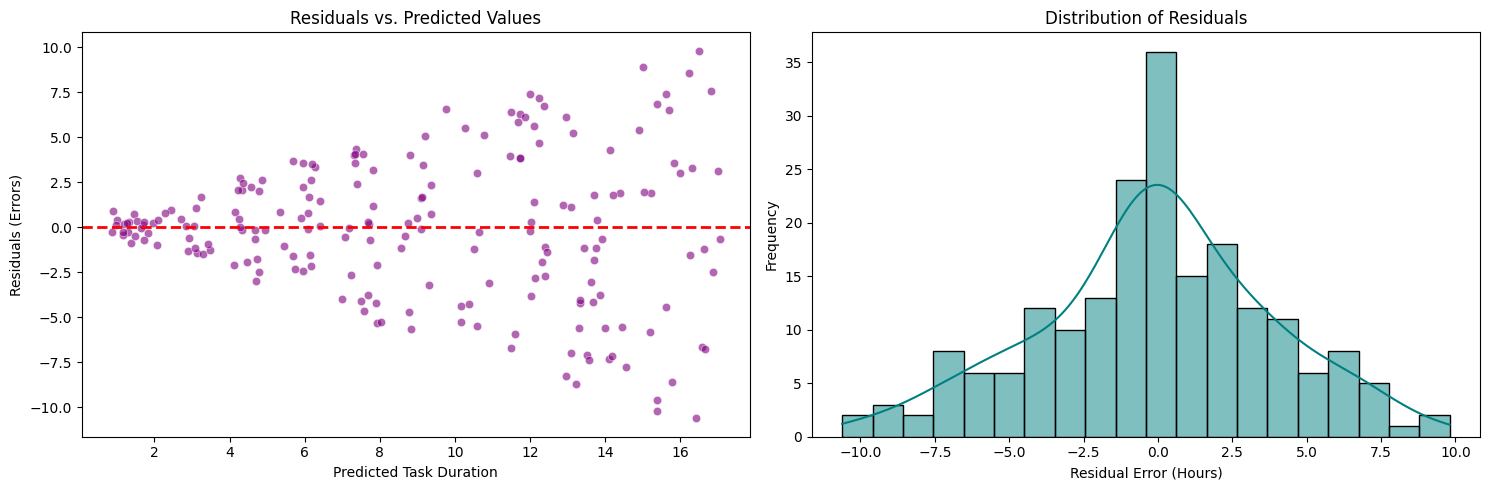

In [11]:
residuals = y_test - y_pred_lr

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(x=y_pred_lr, y=residuals, ax=axes[0], alpha=0.6, color='purple')
axes[0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0].set_title('Residuals vs. Predicted Values')
axes[0].set_xlabel('Predicted Task Duration')
axes[0].set_ylabel('Residuals (Errors)')

sns.histplot(residuals, kde=True, ax=axes[1], color='teal', bins=20)
axes[1].set_title('Distribution of Residuals')
axes[1].set_xlabel('Residual Error (Hours)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


In [12]:
df_eng = df.copy()

df_eng['Total_Active_Hours'] = df_eng['Hours_Coding'] + df_eng['AI_Usage_Hours']
df_eng['AI_to_Manual_Ratio'] = df_eng['AI_Usage_Hours'] / (df_eng['Hours_Coding'] + 0.1) # Add 0.1 to avoid division by zero
df_eng['Lines_per_Hour'] = df_eng['Lines_of_Code'] / (df_eng['Hours_Coding'] + 0.1)
df_eng['Bugs_per_Line'] = df_eng['Bugs_Found'] / df_eng['Lines_of_Code']

expanded_features = feature_cols + [
    'Bugs_Fixed', 
    'Errors', 
    'Total_Active_Hours', 
    'AI_to_Manual_Ratio', 
    'Lines_per_Hour', 
    'Bugs_per_Line'
]

X_eng = df_eng[expanded_features]
y_eng = df_eng['Task_Duration_Hours']

X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(X_eng, y_eng, test_size=0.2, random_state=42)

scaler_eng = StandardScaler()
X_train_eng_scaled = scaler_eng.fit_transform(X_train_eng)
X_test_eng_scaled = scaler_eng.transform(X_test_eng)

print(f"New Feature Set Shape: {X_eng.shape}")


New Feature Set Shape: (1000, 15)


## Gradient Boosting Regressor 

In [13]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_model = GradientBoostingRegressor(
    n_estimators=200, 
    learning_rate=0.05, 
    max_depth=4, 
    subsample=0.8, 
    random_state=42
)

gbr_model.fit(X_train_eng, y_train_eng)

y_pred_gbr = gbr_model.predict(X_test_eng)
mae_gbr = mean_absolute_error(y_test_eng, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_test_eng, y_pred_gbr))

r2_score(y_test_eng, y_pred_gbr)

0.518595493548023

In [14]:
r2_gbr = r2_score(y_test_eng, y_pred_gbr)

print("--- Gradient Boosting Regressor Results ---")
print(f"Mean Absolute Error (MAE): {mae_gbr:.2f} hours")
print(f"Root Mean Squared Error (RMSE): {rmse_gbr:.2f} hours")
print(f"R-squared (R2) Score: {r2_gbr:.4f}")

--- Gradient Boosting Regressor Results ---
Mean Absolute Error (MAE): 3.17 hours
Root Mean Squared Error (RMSE): 4.15 hours
R-squared (R2) Score: 0.5186
